# OpenAlex Author-Institution-Country Analysis

This notebook analyzes the geographic distribution of authors based on their institutional affiliations from the OpenAlex dataset in Azure Cosmos DB.

## Import Required Libraries

In [1]:
import os
from azure.cosmos import CosmosClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Connect to Cosmos DB

Set up connection to the OpenAlex works container.

In [2]:
# Cosmos DB Configuration
COSMOS_ENDPOINT = os.getenv("COSMOS_ENDPOINT", "https://aegiscosmosdb.documents.azure.com")
COSMOS_KEY = os.getenv("COSMOS_KEY", "6Di3nSl2nSG7qitzD8SGYeXuw5rn3eUmC4fha2YswtM5R5hSet8u0hYzMMSnhVBmTfNgMJMxKAbTACDbSPsJpg==")
DATABASE_NAME = "aegisraw"
CONTAINER_NAME = "openalex-works"

# Initialize Cosmos client
client = CosmosClient(COSMOS_ENDPOINT, COSMOS_KEY)
database = client.get_database_client(DATABASE_NAME)
container = database.get_container_client(CONTAINER_NAME)

print(f"Connected to database: {DATABASE_NAME}, container: {CONTAINER_NAME}")

Connected to database: aegisraw, container: openalex-works


## Check Works with/without Institutional Affiliations

First, let's count how many works have at least one authorship with institutions versus those that don't.

Counting works with and without institutional affiliations...

Works WITH institutional affiliations: 347,479 (11.2%)
Works WITHOUT institutional affiliations: 2,757,661 (88.8%)
Total works: 3,105,140


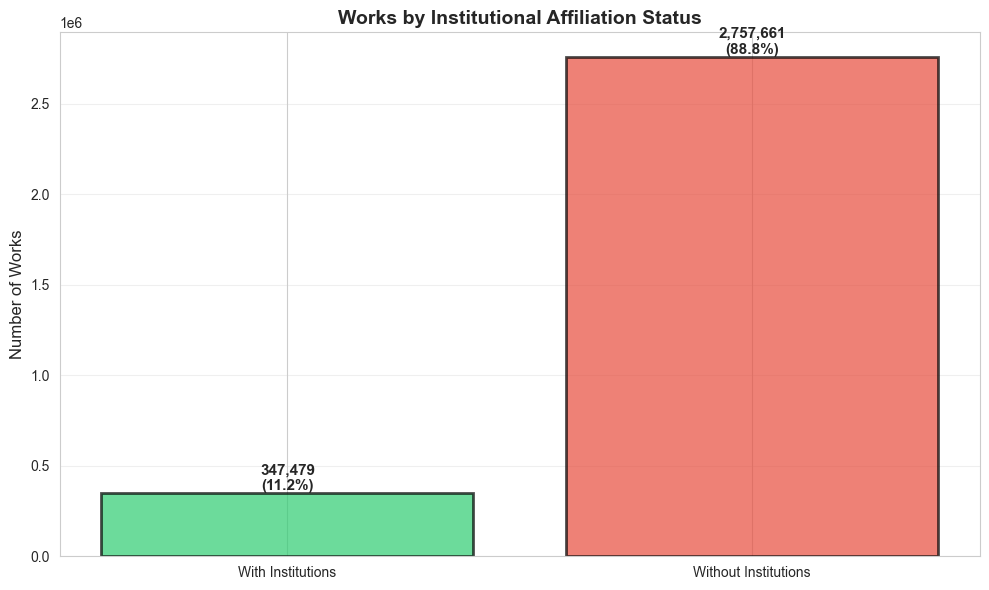

In [14]:
# Query to count works WITH at least one authorship that has institutions
query_with_institutions = """
SELECT VALUE COUNT(1)
FROM c
WHERE EXISTS(
    SELECT VALUE 1
    FROM authorship IN c.authorships
    WHERE IS_DEFINED(authorship.institutions) 
    AND ARRAY_LENGTH(authorship.institutions) > 0
)
"""

# Query to count works WITHOUT any authorship institutions
query_without_institutions = """
SELECT VALUE COUNT(1)
FROM c
WHERE NOT EXISTS(
    SELECT VALUE 1
    FROM authorship IN c.authorships
    WHERE IS_DEFINED(authorship.institutions) 
    AND ARRAY_LENGTH(authorship.institutions) > 0
)
"""

# Execute queries
print("Counting works with and without institutional affiliations...")
print("=" * 80)

with_institutions = list(container.query_items(
    query=query_with_institutions,
    enable_cross_partition_query=True
))[0]

without_institutions = list(container.query_items(
    query=query_without_institutions,
    enable_cross_partition_query=True
))[0]

total = with_institutions + without_institutions

print(f"\nWorks WITH institutional affiliations: {with_institutions:,} ({with_institutions/total*100:.1f}%)")
print(f"Works WITHOUT institutional affiliations: {without_institutions:,} ({without_institutions/total*100:.1f}%)")
print(f"Total works: {total:,}")

# Visualize
plt.figure(figsize=(10, 6))
labels = ['With Institutions', 'Without Institutions']
counts = [with_institutions, without_institutions]
colors = ['#2ecc71', '#e74c3c']

plt.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
plt.ylabel('Number of Works', fontsize=12)
plt.title('Works by Institutional Affiliation Status', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count, f'{count:,}\n({count/total*100:.1f}%)', 
             ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

## Check Authors with/without Institutional Affiliations

Now let's analyze how many unique authors have at least one institution listed versus those with no institutions.

Querying author institutional affiliation status...
Authors WITH institutions: 515,094
Total unique authors: 4,351,333
Authors WITHOUT institutions: 3,836,239

Percentage breakdown:
  With institutions: 11.8%
  Without institutions: 88.2%


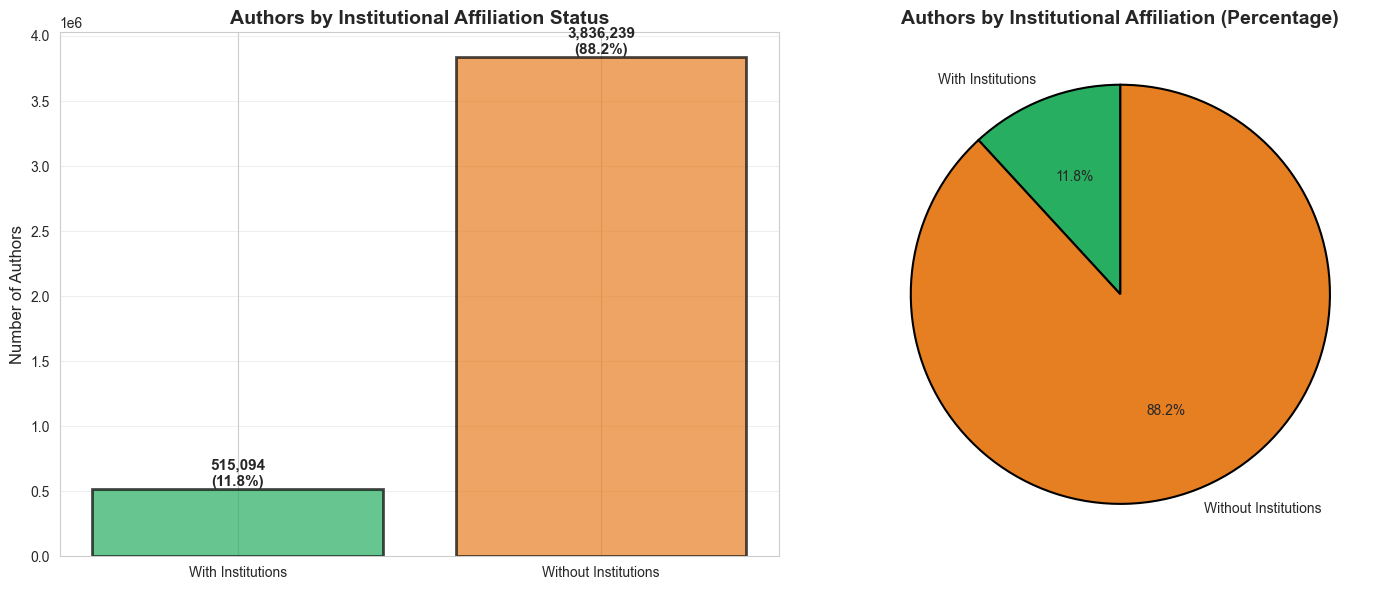

In [15]:
# Query for all unique authors WITH institutions
query_authors_with_inst = """
SELECT DISTINCT VALUE authorship.author.id
FROM c
JOIN authorship IN c.authorships
JOIN institution IN authorship.institutions
WHERE IS_DEFINED(authorship.author.id)
AND IS_DEFINED(institution.id)
"""

# Query for ALL unique authors
query_all_authors = """
SELECT DISTINCT VALUE authorship.author.id
FROM c
JOIN authorship IN c.authorships
WHERE IS_DEFINED(authorship.author.id)
"""

print("Querying author institutional affiliation status...")
print("=" * 80)

# Get authors with institutions
authors_with_inst = set(container.query_items(
    query=query_authors_with_inst,
    enable_cross_partition_query=True
))

print(f"Authors WITH institutions: {len(authors_with_inst):,}")

# Get all authors
all_authors = set(container.query_items(
    query=query_all_authors,
    enable_cross_partition_query=True
))

print(f"Total unique authors: {len(all_authors):,}")


Authors WITHOUT institutions: 3,836,239

Percentage breakdown:
  With institutions: 11.8%
  Without institutions: 88.2%


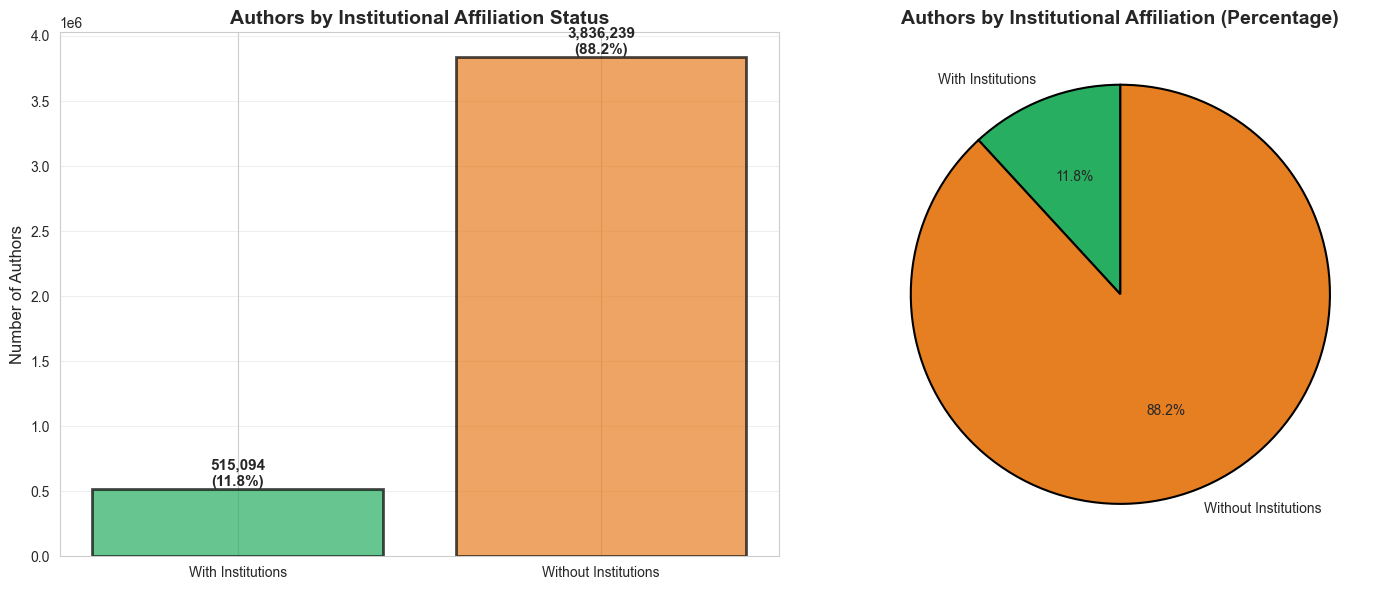

In [16]:

# Calculate authors without institutions
authors_without_inst = all_authors - authors_with_inst

print(f"Authors WITHOUT institutions: {len(authors_without_inst):,}")
print(f"\nPercentage breakdown:")
print(f"  With institutions: {len(authors_with_inst)/len(all_authors)*100:.1f}%")
print(f"  Without institutions: {len(authors_without_inst)/len(all_authors)*100:.1f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
labels = ['With Institutions', 'Without Institutions']
counts = [len(authors_with_inst), len(authors_without_inst)]
colors = ['#27ae60', '#e67e22']

axes[0].bar(labels, counts, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Number of Authors', fontsize=12)
axes[0].set_title('Authors by Institutional Affiliation Status', fontsize=14, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add count labels on bars
for i, (label, count) in enumerate(zip(labels, counts)):
    axes[0].text(i, count, f'{count:,}\n({count/len(all_authors)*100:.1f}%)', 
                 ha='center', va='bottom', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, 
            colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Authors by Institutional Affiliation (Percentage)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Multiple Institutions per Author per Work

Analyze how often authors list multiple institutional affiliations on a single work.

In [17]:
# Query to get institution counts per author per work
query_multi_inst = """
SELECT 
    c.id as work_id,
    authorship.author.id as author_id,
    authorship.author.display_name as author_name,
    ARRAY_LENGTH(authorship.institutions) as num_institutions
FROM c
JOIN authorship IN c.authorships
WHERE IS_DEFINED(authorship.author.id)
AND IS_DEFINED(authorship.institutions)
"""

print("Analyzing institutional affiliations per author per work...")
print("=" * 80)

# Fetch data
multi_inst_items = list(container.query_items(
    query=query_multi_inst,
    enable_cross_partition_query=True,
    max_item_count=10000
))

# Create DataFrame
multi_inst_df = pd.DataFrame(multi_inst_items)

print(f"\nTotal author-work records: {len(multi_inst_df):,}")
print(f"Unique works: {multi_inst_df['work_id'].nunique():,}")
print(f"Unique authors: {multi_inst_df['author_id'].nunique():,}")

# Analyze distribution
print("\nInstitutions per Author per Work:")
print(multi_inst_df['num_institutions'].describe())

# Count by category
with_0_inst = (multi_inst_df['num_institutions'] == 0).sum()
with_1_inst = (multi_inst_df['num_institutions'] == 1).sum()
with_2_inst = (multi_inst_df['num_institutions'] == 2).sum()
with_3plus_inst = (multi_inst_df['num_institutions'] >= 3).sum()
total_authorships = len(multi_inst_df)

print(f"\nBreakdown:")
print(f"  0 institutions: {with_0_inst:,} ({with_0_inst/total_authorships*100:.1f}%)")
print(f"  1 institution: {with_1_inst:,} ({with_1_inst/total_authorships*100:.1f}%)")
print(f"  2 institutions: {with_2_inst:,} ({with_2_inst/total_authorships*100:.1f}%)")
print(f"  3+ institutions: {with_3plus_inst:,} ({with_3plus_inst/total_authorships*100:.1f}%)")

# Key metric
multiple_inst = (multi_inst_df['num_institutions'] > 1).sum()
print(f"\nAuthors listing multiple institutions on a work: {multiple_inst:,} ({multiple_inst/total_authorships*100:.1f}%)")

# Find examples of high multi-affiliation
print("\nTop 10 Authors with Most Institutions on a Single Work:")
top_multi = multi_inst_df.nlargest(10, 'num_institutions')[['author_name', 'num_institutions', 'work_id']]
print(top_multi.to_string(index=False))

Analyzing institutional affiliations per author per work...

Total author-work records: 6,416,635
Unique works: 3,066,219
Unique authors: 4,370,758

Institutions per Author per Work:
count    6.416635e+06
mean     1.035156e-01
std      3.352502e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      7.000000e+00
Name: num_institutions, dtype: float64

Breakdown:
  0 institutions: 5,808,840 (90.5%)
  1 institution: 556,393 (8.7%)
  2 institutions: 47,433 (0.7%)
  3+ institutions: 3,969 (0.1%)

Authors listing multiple institutions on a work: 51,402 (0.8%)

Top 10 Authors with Most Institutions on a Single Work:
      author_name  num_institutions     work_id
    Didier Dubois                 7   W14187391
  Patrick Amestoy                 7   W39106074
     Michel Daydé                 7   W39106074
Jean-Marc Douguet                 7 W4414575425
    Mathieu Roche                 7 W4414575425
      Abel Guihou                 7 W3024399597
 

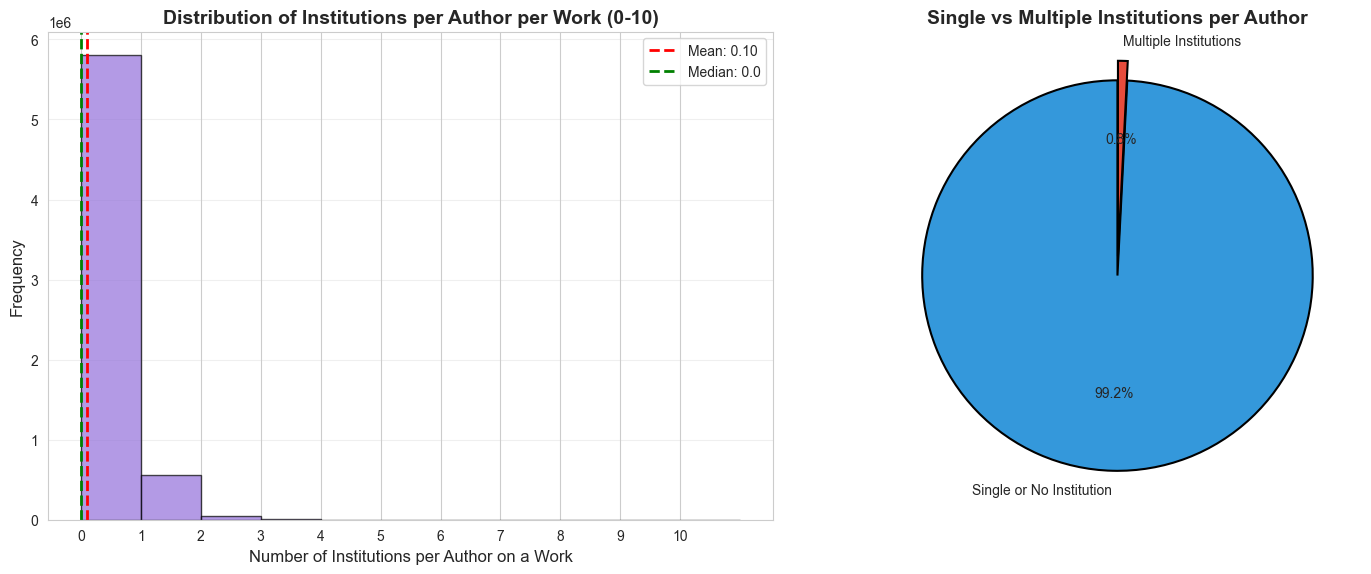

In [18]:
# Visualize distribution of institutions per author per work
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for 0-10 institutions
filtered_inst = multi_inst_df[multi_inst_df['num_institutions'] <= 10]['num_institutions']
axes[0].hist(filtered_inst, bins=range(0, 12), edgecolor='black', alpha=0.7, color='mediumpurple')
axes[0].set_xlabel('Number of Institutions per Author on a Work', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].set_title('Distribution of Institutions per Author per Work (0-10)', fontsize=14, fontweight='bold')
axes[0].axvline(multi_inst_df['num_institutions'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f'Mean: {multi_inst_df["num_institutions"].mean():.2f}')
axes[0].axvline(multi_inst_df['num_institutions'].median(), color='green', linestyle='--', linewidth=2, 
                label=f'Median: {multi_inst_df["num_institutions"].median():.1f}')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_xticks(range(0, 11))

# Pie chart for single vs multiple institutions
single_inst_count = (multi_inst_df['num_institutions'] <= 1).sum()
multiple_inst_count = (multi_inst_df['num_institutions'] > 1).sum()

labels = ['Single or No Institution', 'Multiple Institutions']
sizes = [single_inst_count, multiple_inst_count]
colors = ['#3498db', '#e74c3c']
explode = (0, 0.1)

axes[1].pie(sizes, explode=explode, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=colors, wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
axes[1].set_title('Single vs Multiple Institutions per Author', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# Analyze patterns: which authors consistently use multiple institutions?
author_multi_inst_stats = multi_inst_df.groupby('author_id').agg({
    'num_institutions': ['mean', 'max', 'min'],
    'author_name': 'first',
    'work_id': 'count'
}).reset_index()

# Flatten column names
author_multi_inst_stats.columns = ['author_id', 'avg_institutions', 'max_institutions', 
                                     'min_institutions', 'author_name', 'num_works']

# Filter authors with at least 3 works for meaningful analysis
frequent_authors = author_multi_inst_stats[author_multi_inst_stats['num_works'] >= 3]

print(f"\nAuthors with Multiple Institution Patterns (min 3 works):")
print("=" * 80)
print(f"Total authors with 3+ works: {len(frequent_authors):,}")

# Authors who consistently list multiple institutions
consistent_multi = frequent_authors[frequent_authors['avg_institutions'] >= 2]
print(f"Authors averaging 2+ institutions per work: {len(consistent_multi):,} ({len(consistent_multi)/len(frequent_authors)*100:.1f}%)")

# Top authors by average institutions
print("\nTop 15 Authors by Average Institutions per Work (min 3 works):")
top_avg_multi = frequent_authors.nlargest(15, 'avg_institutions')[['author_name', 'num_works', 'avg_institutions', 'max_institutions']]
print(top_avg_multi.to_string(index=False))

# Visualize
plt.figure(figsize=(12, 6))
plt.scatter(frequent_authors['num_works'], frequent_authors['avg_institutions'], 
            alpha=0.5, s=20, color='darkblue')
plt.xlabel('Number of Works', fontsize=12)
plt.ylabel('Average Institutions per Work', fontsize=12)
plt.title('Author Work Count vs Average Institutions per Work', fontsize=14, fontweight='bold')
plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='1 institution threshold')
plt.axhline(y=2, color='orange', linestyle='--', linewidth=1, label='2 institutions threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Query Author-Institution-Country Data

Use JOIN operations to flatten the nested authorships and institutions arrays.

In [3]:
# Query for author-institution-country relationships
query = """
SELECT 
    c.id as work_id,
    c.title,
    c.publication_year,
    authorship.author.id as author_id,
    authorship.author.display_name as author_name,
    institution.id as institution_id,
    institution.display_name as institution_name,
    institution.country_code as country_code
FROM c
JOIN authorship IN c.authorships
JOIN institution IN authorship.institutions
WHERE IS_DEFINED(institution.country_code)
"""

# Fetch documents
items = list(container.query_items(
    query=query,
    enable_cross_partition_query=True,
    max_item_count=10000
))

print(f"Fetched {len(items):,} author-institution-country records")

Fetched 627,344 author-institution-country records


## Create DataFrame and Basic Statistics

In [4]:
# Create DataFrame
df = pd.DataFrame(items)

print(f"\nDataFrame created with {len(df):,} rows")
print(f"\nColumns: {list(df.columns)}")
print(f"\nBasic info:")
print(f"  Unique works: {df['work_id'].nunique():,}")
print(f"  Unique authors: {df['author_id'].nunique():,}")
print(f"  Unique institutions: {df['institution_id'].nunique():,}")
print(f"  Unique countries: {df['country_code'].nunique():,}")

print(f"\nFirst few rows:")
print(df.head(10))


DataFrame created with 627,344 rows

Columns: ['work_id', 'title', 'publication_year', 'author_id', 'author_name', 'institution_id', 'institution_name', 'country_code']

Basic info:
  Unique works: 345,376
  Unique authors: 494,748
  Unique institutions: 25,180
  Unique countries: 197

First few rows:
       work_id                                              title  \
0  W1522794414  PUBLIC SERVICE DELIVERY AND JOINT-UP GOVERNANC...   
1   W306868851  Rancang Bangun Penggerak Otomatis Panel Surya ...   
2  W1483817720  BATIK FRAKTAL: PERKEMBANGAN APLIKASI GEOMETRI ...   
3  W1525514410        Methodology and Application of Oneway ANOVA   
4  W1545959690  CRÉDITO RURAL. ASSISTÊNCIA TÉCNICA. PRODUTIVID...   
5  W1516959002  STUDI KEPEDULIAN LAKI-LAKI TERHADAP KESEHATAN ...   
6  W1516959002  STUDI KEPEDULIAN LAKI-LAKI TERHADAP KESEHATAN ...   
7  W1480302865  Bull Gore injury- Its impact and surgical mana...   
8  W1480302865  Bull Gore injury- Its impact and surgical mana...   
9  W14

## Country Distribution Analysis

Analyze the distribution of authors and works across countries.

Country Statistics (Top 20):
              unique_authors  unique_works  unique_institutions
country_code                                                   
CN                    147113        147583                 3447
US                     71982         44109                 4526
BR                     28399         14575                  714
JP                     20208          8568                 1251
ID                     17621          9716                  478
PL                     15903         13541                  526
GB                     15659         12052                  922
IR                     12184          4986                  330
MX                     11457          7841                  292
DE                     11214          6673                  774
FR                     11139          8233                 1473
IN                     10884          5551                 1292
ES                     10861          7168                  557
IT         

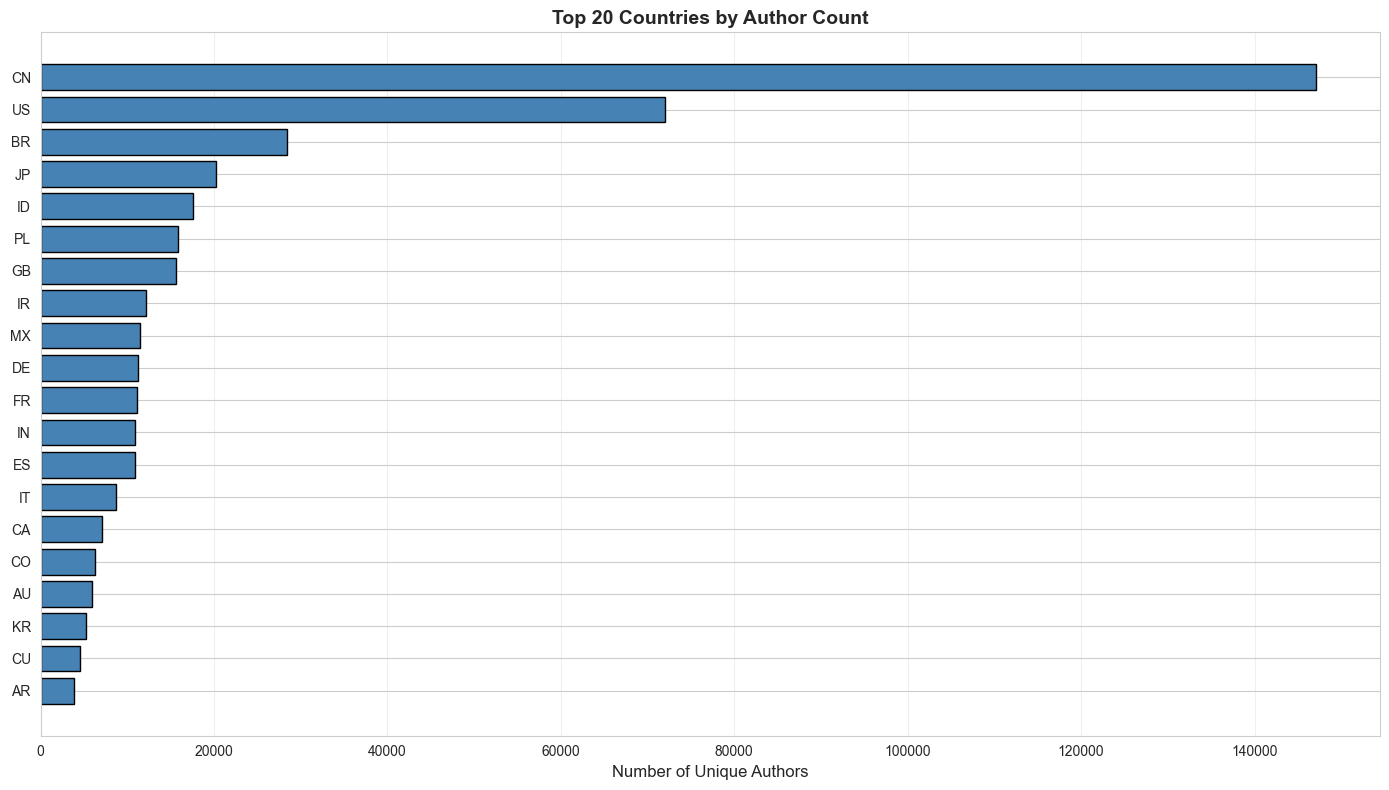

In [5]:
# Count authors and works per country
country_stats = df.groupby('country_code').agg({
    'author_id': 'nunique',
    'work_id': 'nunique',
    'institution_id': 'nunique'
}).rename(columns={
    'author_id': 'unique_authors',
    'work_id': 'unique_works',
    'institution_id': 'unique_institutions'
}).sort_values('unique_authors', ascending=False)

print("Country Statistics (Top 20):")
print("=" * 80)
print(country_stats.head(20))

# Visualize top 20 countries by author count
plt.figure(figsize=(14, 8))
top_countries = country_stats.head(20)
plt.barh(range(len(top_countries)), top_countries['unique_authors'], color='steelblue', edgecolor='black')
plt.yticks(range(len(top_countries)), top_countries.index)
plt.xlabel('Number of Unique Authors', fontsize=12)
plt.title('Top 20 Countries by Author Count', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Works by Country

Analyze the distribution of works across countries.

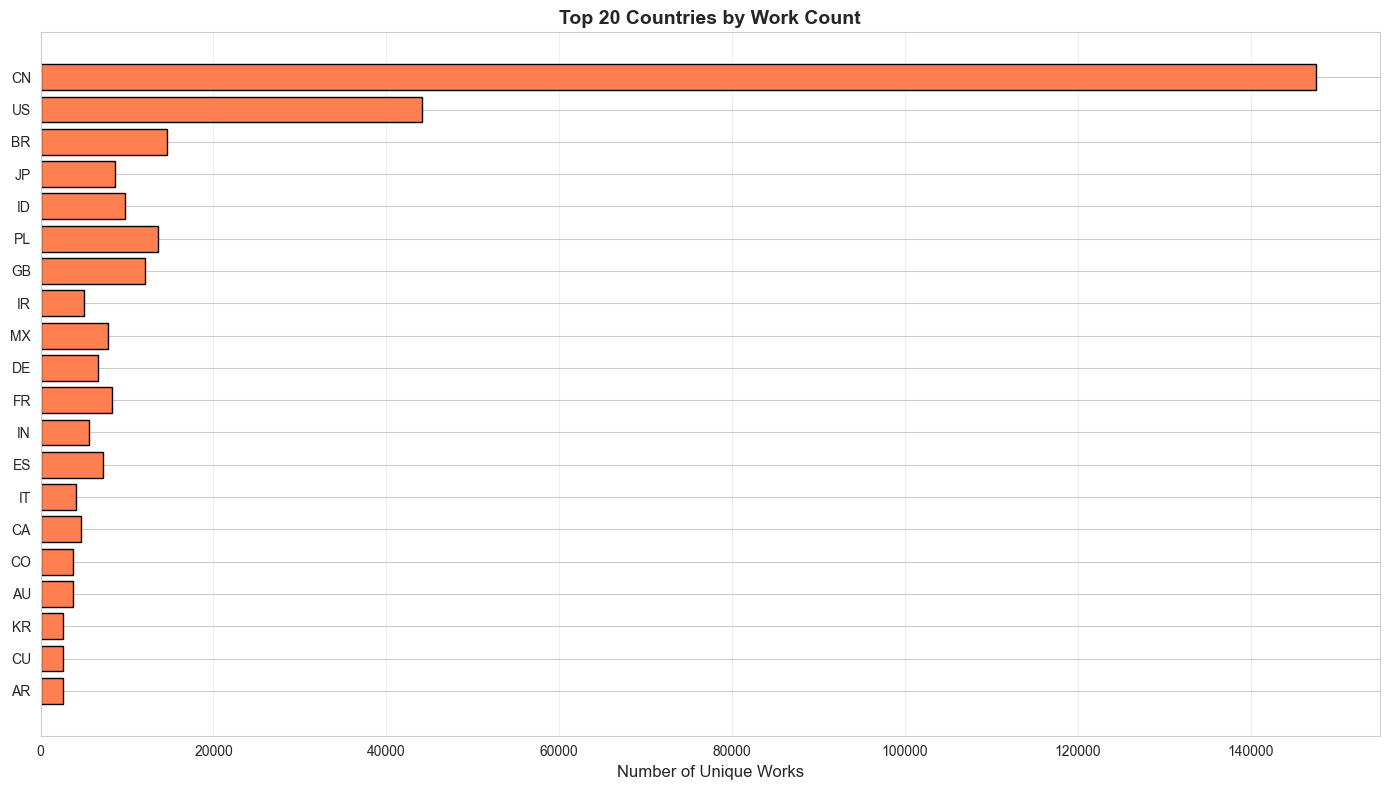

In [6]:
# Visualize top 20 countries by work count
plt.figure(figsize=(14, 8))
top_countries_works = country_stats['unique_works'].head(20)
plt.barh(range(len(top_countries_works)), top_countries_works.values, color='coral', edgecolor='black')
plt.yticks(range(len(top_countries_works)), top_countries_works.index)
plt.xlabel('Number of Unique Works', fontsize=12)
plt.title('Top 20 Countries by Work Count', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Author Geographic Diversity

Analyze how many countries each author is associated with (through institutional affiliations).

Author Geographic Diversity Statistics:
count    494748.000000
mean          1.023139
std           0.160023
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max           6.000000
Name: num_countries, dtype: float64

Authors with 1 country: 483,943 (97.8%)
Authors with 2+ countries: 10,805 (2.2%)
Authors with 5+ countries: 10 (0.0%)

Top 15 Authors by Number of Countries:
                                  num_countries            author_name  num_institutions  num_works
author_id                                                                                          
https://openalex.org/A5015180558              6      Laurie Richardson                 6          1
https://openalex.org/A5025127172              6        Andy Williamson                 6          1
https://openalex.org/A5029479997              6            Dave Hodges                 6          1
https://openalex.org/A5083155644              6            Phil Coogan           

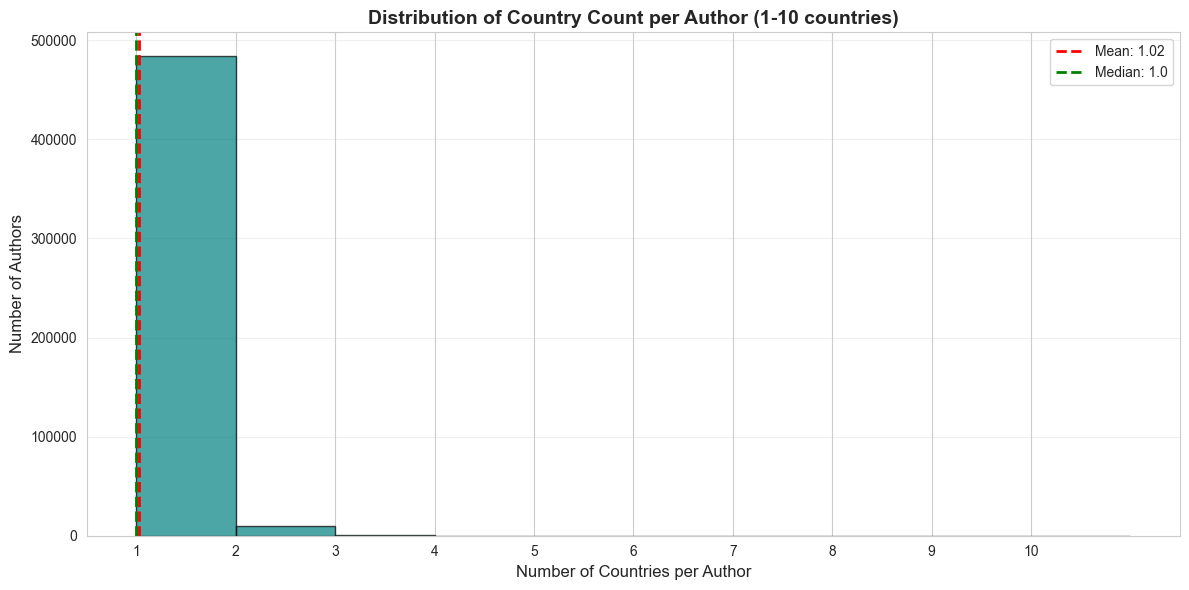

In [7]:
# Count countries per author
author_countries = df.groupby('author_id').agg({
    'country_code': lambda x: x.nunique(),
    'author_name': 'first',
    'institution_id': 'nunique',
    'work_id': 'nunique'
}).rename(columns={
    'country_code': 'num_countries',
    'institution_id': 'num_institutions',
    'work_id': 'num_works'
})

print("Author Geographic Diversity Statistics:")
print("=" * 80)
print(author_countries['num_countries'].describe())
print(f"\nAuthors with 1 country: {(author_countries['num_countries'] == 1).sum():,} ({(author_countries['num_countries'] == 1).mean()*100:.1f}%)")
print(f"Authors with 2+ countries: {(author_countries['num_countries'] >= 2).sum():,} ({(author_countries['num_countries'] >= 2).mean()*100:.1f}%)")
print(f"Authors with 5+ countries: {(author_countries['num_countries'] >= 5).sum():,} ({(author_countries['num_countries'] >= 5).mean()*100:.1f}%)")

# Top authors by number of countries
print("\nTop 15 Authors by Number of Countries:")
top_mobile_authors = author_countries.nlargest(15, 'num_countries')
print(top_mobile_authors.to_string())

# Visualize distribution
plt.figure(figsize=(12, 6))
countries_per_author = author_countries['num_countries']
filtered = countries_per_author[countries_per_author <= 10]
plt.hist(filtered, bins=range(1, 12), edgecolor='black', alpha=0.7, color='teal')
plt.xlabel('Number of Countries per Author', fontsize=12)
plt.ylabel('Number of Authors', fontsize=12)
plt.title('Distribution of Country Count per Author (1-10 countries)', fontsize=14, fontweight='bold')
plt.axvline(countries_per_author.mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {countries_per_author.mean():.2f}')
plt.axvline(countries_per_author.median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {countries_per_author.median():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(1, 11))
plt.tight_layout()
plt.show()

## Institution Distribution by Country

Analyze how institutions are distributed across countries.

Top 20 Countries by Number of Institutions:
country_code
US    4526
CN    3447
FR    1473
IN    1292
JP    1251
GB     922
DE     774
BR     714
RU     558
ES     557
PL     526
IT     513
ID     478
CA     441
KR     347
IR     330
MX     292
AU     280
TR     247
TW     232
Name: institution_id, dtype: int64


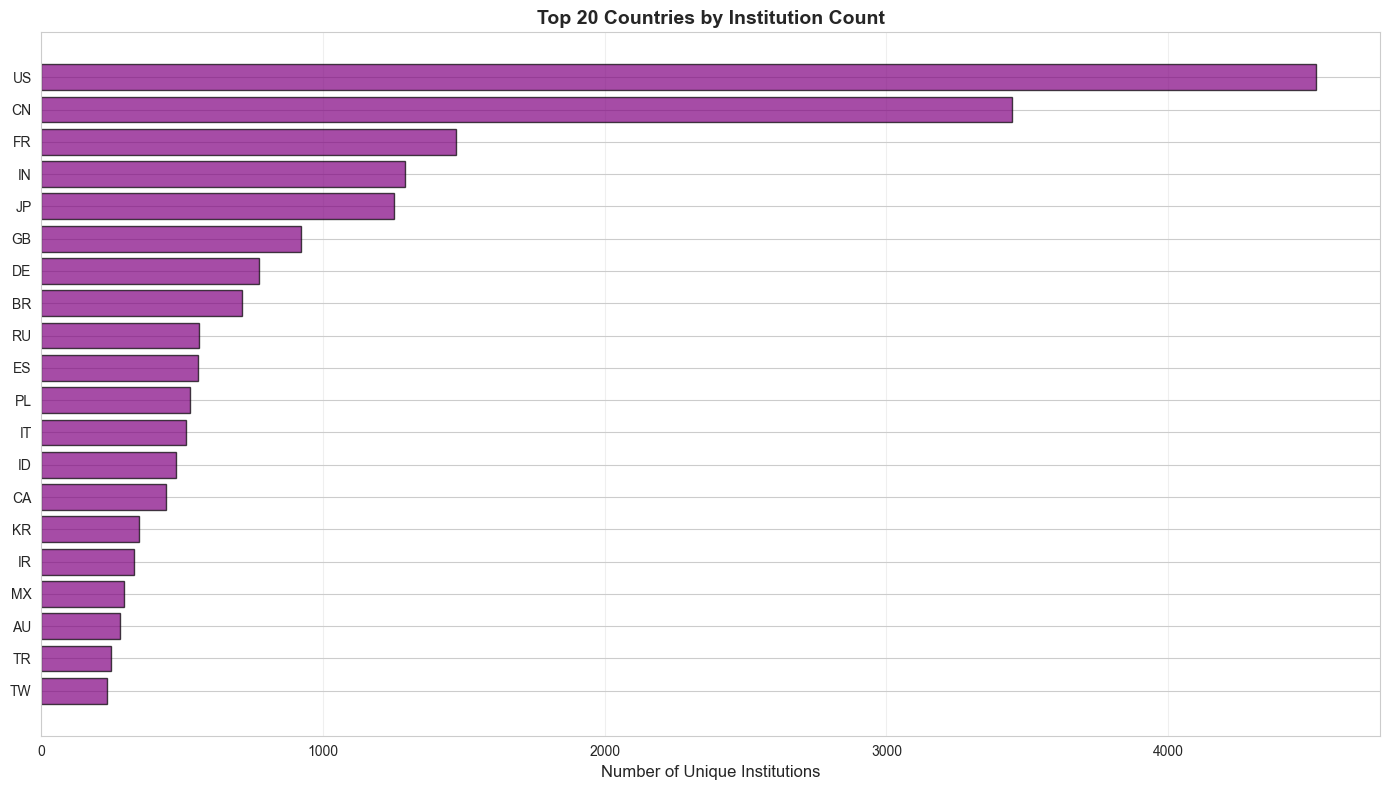

In [8]:
# Institutions per country
inst_per_country = df.groupby('country_code')['institution_id'].nunique().sort_values(ascending=False)

print("Top 20 Countries by Number of Institutions:")
print("=" * 80)
print(inst_per_country.head(20))

# Visualize
plt.figure(figsize=(14, 8))
top_inst_countries = inst_per_country.head(20)
plt.barh(range(len(top_inst_countries)), top_inst_countries.values, color='purple', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_inst_countries)), top_inst_countries.index)
plt.xlabel('Number of Unique Institutions', fontsize=12)
plt.title('Top 20 Countries by Institution Count', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Country Concentration Analysis

Analyze the concentration of authors across countries (using Herfindahl-Hirschman Index).

Country Concentration Analysis:
Herfindahl-Hirschman Index (HHI): 0.1172
  (0 = perfectly distributed, 1 = complete concentration)

Top 5 countries represent: 0.1% of authors
Top 10 countries represent: 1.1% of authors
Top 20 countries represent: 3.2% of authors


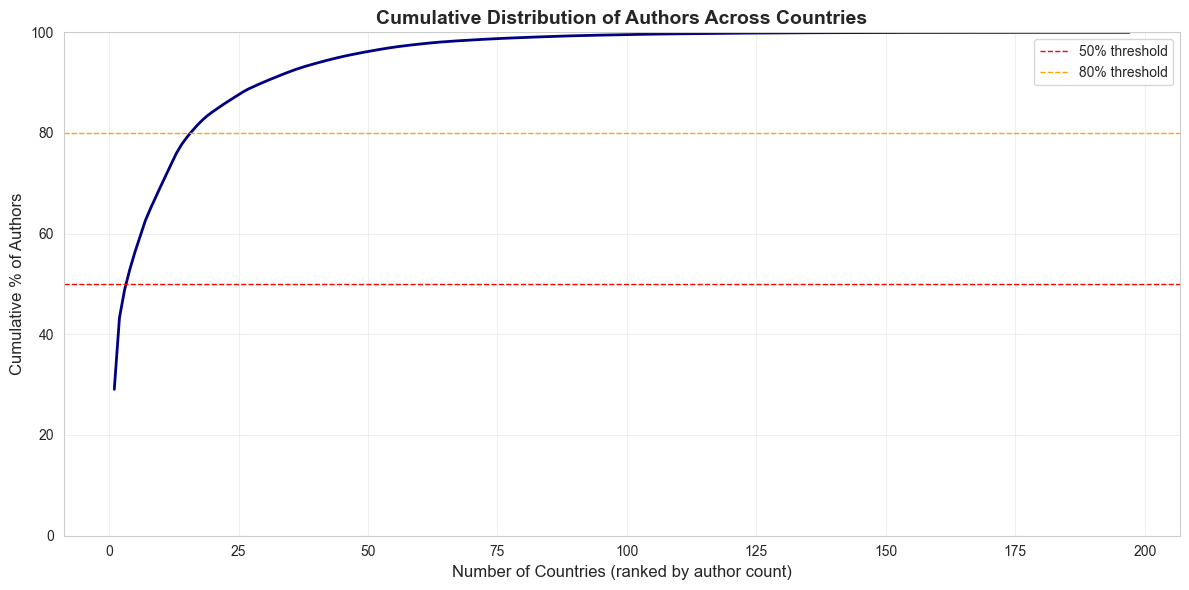

In [9]:
# Calculate HHI for country concentration
def calculate_hhi(counts):
    """Calculate Herfindahl-Hirschman Index (HHI) for concentration."""
    total = counts.sum()
    shares = counts / total
    hhi = (shares ** 2).sum()
    return hhi

country_author_counts = df.groupby('country_code')['author_id'].nunique()
hhi = calculate_hhi(country_author_counts)

print("Country Concentration Analysis:")
print("=" * 80)
print(f"Herfindahl-Hirschman Index (HHI): {hhi:.4f}")
print(f"  (0 = perfectly distributed, 1 = complete concentration)")
print(f"\nTop 5 countries represent: {country_author_counts.head(5).sum() / country_author_counts.sum() * 100:.1f}% of authors")
print(f"Top 10 countries represent: {country_author_counts.head(10).sum() / country_author_counts.sum() * 100:.1f}% of authors")
print(f"Top 20 countries represent: {country_author_counts.head(20).sum() / country_author_counts.sum() * 100:.1f}% of authors")

# Cumulative distribution
cumulative_pct = (country_author_counts.sort_values(ascending=False).cumsum() / country_author_counts.sum() * 100)

plt.figure(figsize=(12, 6))
plt.plot(range(1, len(cumulative_pct) + 1), cumulative_pct.values, linewidth=2, color='navy')
plt.axhline(y=50, color='red', linestyle='--', linewidth=1, label='50% threshold')
plt.axhline(y=80, color='orange', linestyle='--', linewidth=1, label='80% threshold')
plt.xlabel('Number of Countries (ranked by author count)', fontsize=12)
plt.ylabel('Cumulative % of Authors', fontsize=12)
plt.title('Cumulative Distribution of Authors Across Countries', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

## Country Co-occurrence Analysis

Analyze which countries frequently collaborate (appear on the same works).

International Collaboration Statistics:
Total works: 345,376
Single-country works: 329,464 (95.4%)
Multi-country works: 15,912 (4.6%)
Works with 5+ countries: 161
Max countries on one work: 51


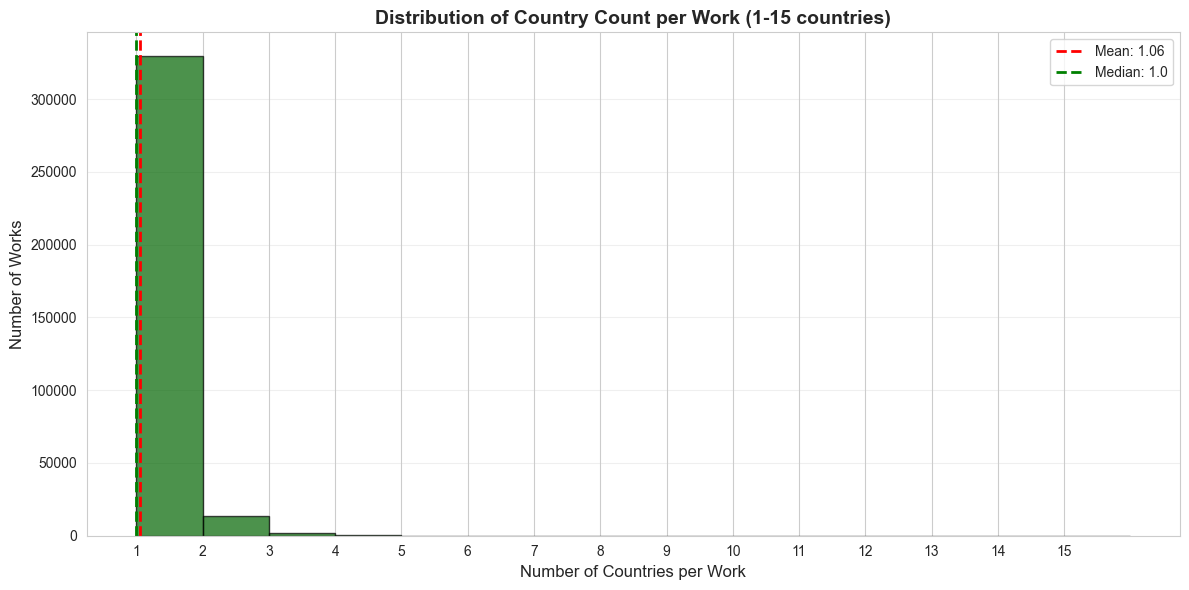

In [10]:
# Find works with multiple countries
works_countries = df.groupby('work_id')['country_code'].apply(lambda x: sorted(set(x))).reset_index()
works_countries['num_countries'] = works_countries['country_code'].apply(len)

print("International Collaboration Statistics:")
print("=" * 80)
print(f"Total works: {len(works_countries):,}")
print(f"Single-country works: {(works_countries['num_countries'] == 1).sum():,} ({(works_countries['num_countries'] == 1).mean()*100:.1f}%)")
print(f"Multi-country works: {(works_countries['num_countries'] > 1).sum():,} ({(works_countries['num_countries'] > 1).mean()*100:.1f}%)")
print(f"Works with 5+ countries: {(works_countries['num_countries'] >= 5).sum():,}")
print(f"Max countries on one work: {works_countries['num_countries'].max()}")

# Visualize distribution
plt.figure(figsize=(12, 6))
filtered_collab = works_countries[works_countries['num_countries'] <= 15]['num_countries']
plt.hist(filtered_collab, bins=range(1, 17), edgecolor='black', alpha=0.7, color='darkgreen')
plt.xlabel('Number of Countries per Work', fontsize=12)
plt.ylabel('Number of Works', fontsize=12)
plt.title('Distribution of Country Count per Work (1-15 countries)', fontsize=14, fontweight='bold')
plt.axvline(works_countries['num_countries'].mean(), color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {works_countries["num_countries"].mean():.2f}')
plt.axvline(works_countries['num_countries'].median(), color='green', linestyle='--', linewidth=2, 
            label=f'Median: {works_countries["num_countries"].median():.1f}')
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.xticks(range(1, 16))
plt.tight_layout()
plt.show()

## Top Country Pairs in Collaborations

Identify the most common country pairs in multi-country works.

Top 20 Country Collaboration Pairs:
GB - US: 781 works
CN - US: 688 works
DE - US: 569 works
CA - US: 522 works
FR - US: 356 works
JP - US: 342 works
IT - US: 284 works
AU - US: 265 works
DE - GB: 258 works
NL - US: 219 works
AU - CN: 208 works
FR - GB: 205 works
IL - US: 184 works
KR - US: 175 works
ES - US: 175 works
GB - IT: 174 works
BR - US: 173 works
IN - US: 169 works
AU - GB: 167 works
DE - FR: 166 works


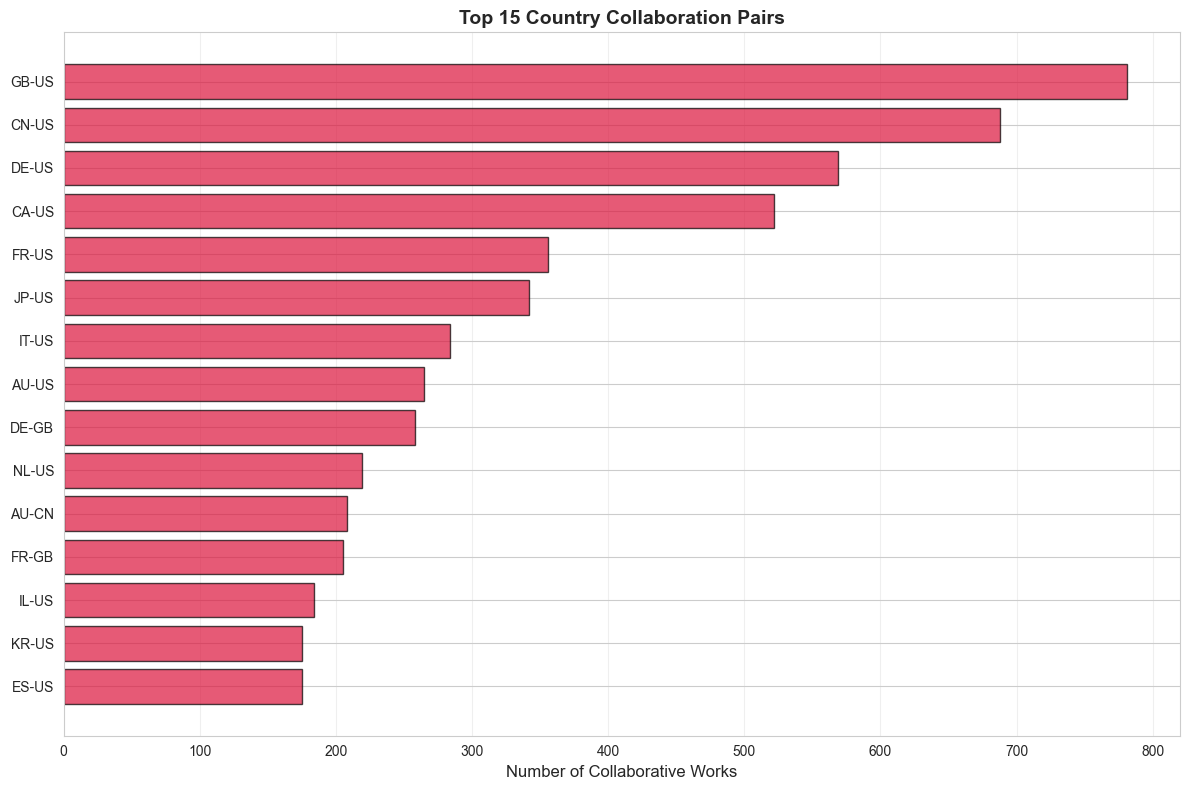

In [11]:
from itertools import combinations

# Extract country pairs from multi-country works
country_pairs = []
for countries_list in works_countries[works_countries['num_countries'] > 1]['country_code']:
    # Generate all pairs from the country list
    pairs = list(combinations(sorted(countries_list), 2))
    country_pairs.extend(pairs)

# Count pairs
pair_counts = Counter(country_pairs)

print("Top 20 Country Collaboration Pairs:")
print("=" * 80)
for pair, count in pair_counts.most_common(20):
    print(f"{pair[0]} - {pair[1]}: {count:,} works")

# Visualize top 15 pairs
plt.figure(figsize=(12, 8))
top_pairs = pair_counts.most_common(15)
pair_labels = [f"{p[0]}-{p[1]}" for p, c in top_pairs]
pair_values = [c for p, c in top_pairs]

plt.barh(range(len(top_pairs)), pair_values, color='crimson', alpha=0.7, edgecolor='black')
plt.yticks(range(len(top_pairs)), pair_labels)
plt.xlabel('Number of Collaborative Works', fontsize=12)
plt.title('Top 15 Country Collaboration Pairs', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Temporal Analysis (if publication year available)

Analyze how country distributions change over time.

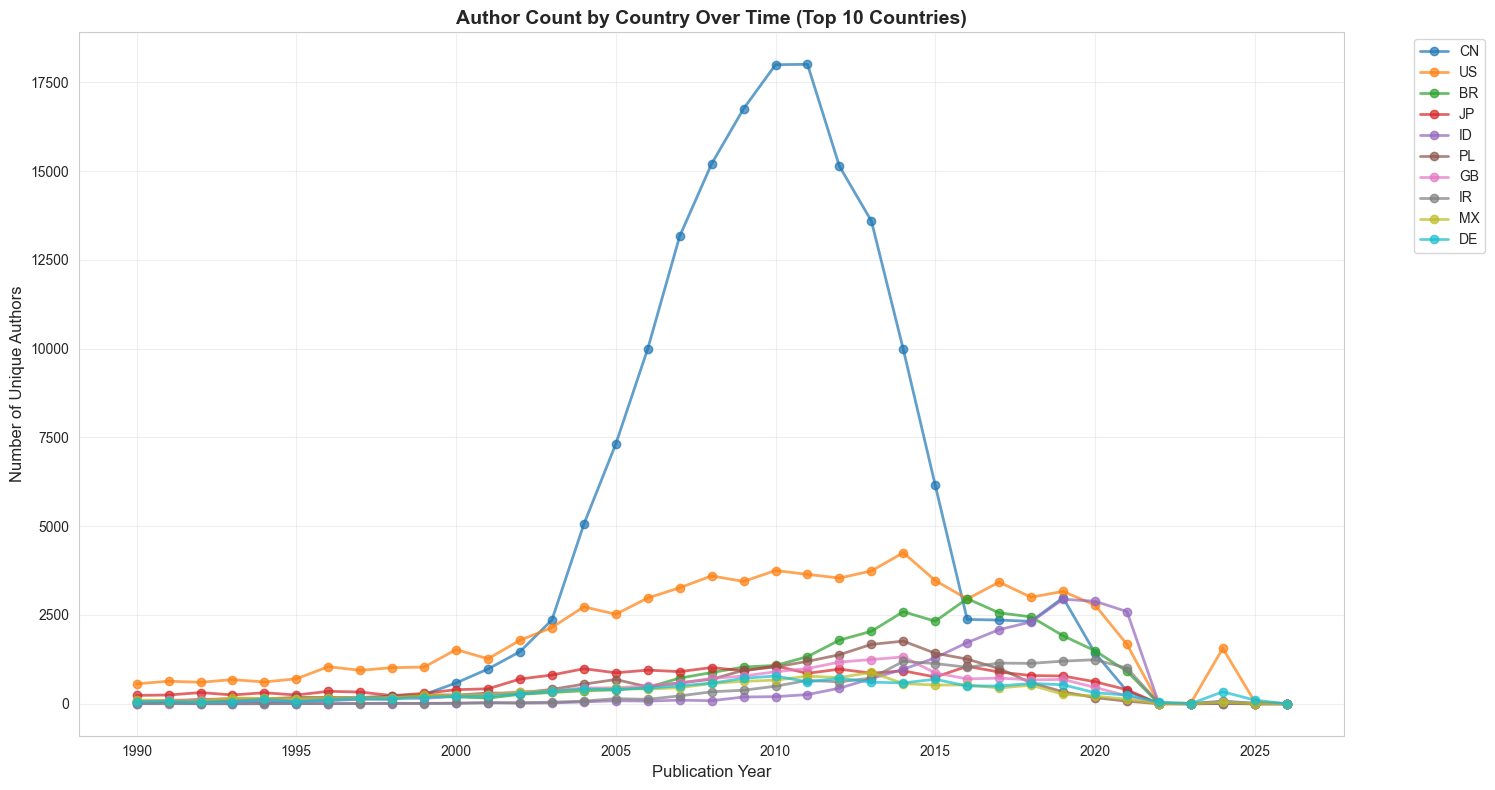

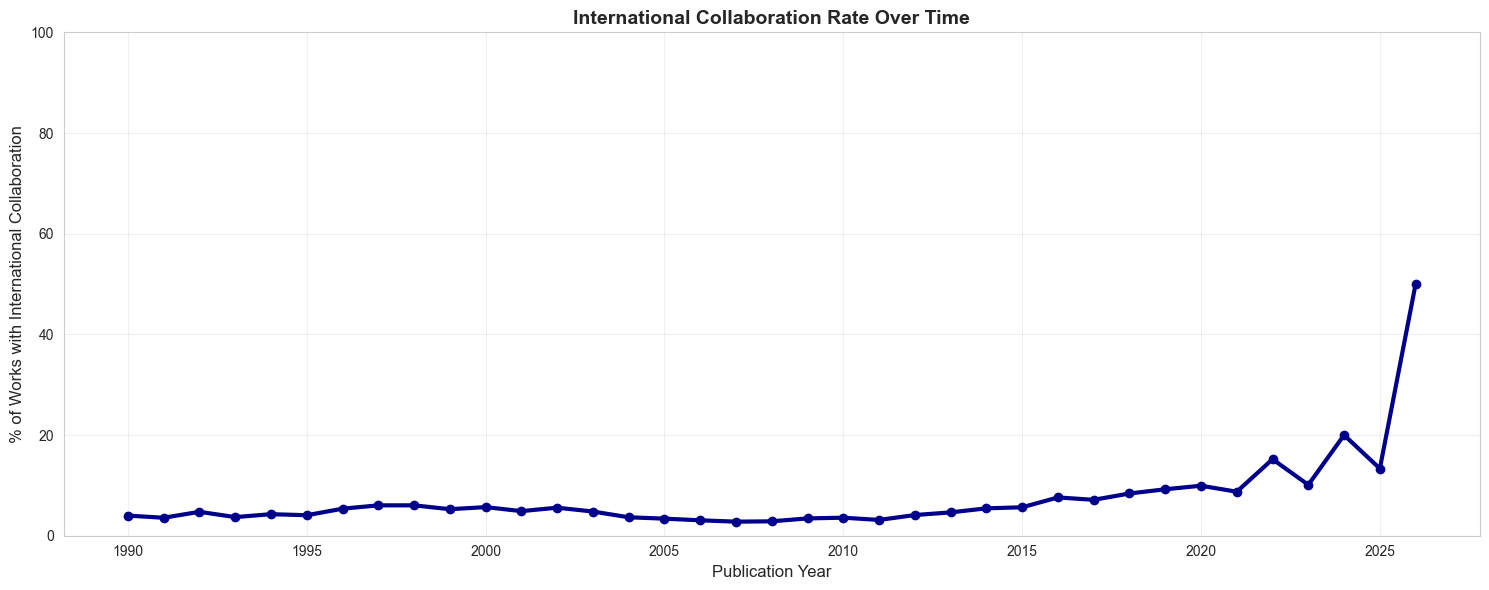

In [12]:
# Check if publication year is available
if 'publication_year' in df.columns and df['publication_year'].notna().any():
    # Filter valid years
    df_temporal = df[(df['publication_year'].notna()) & 
                     (df['publication_year'] >= 1990) & 
                     (df['publication_year'] <= 2026)]
    
    # Top 10 countries over time
    top_10_countries = country_stats.head(10).index
    
    # Count authors per year for top countries
    temporal_data = []
    for year in sorted(df_temporal['publication_year'].unique()):
        year_data = df_temporal[df_temporal['publication_year'] == year]
        for country in top_10_countries:
            count = year_data[year_data['country_code'] == country]['author_id'].nunique()
            temporal_data.append({
                'year': year,
                'country': country,
                'author_count': count
            })
    
    temporal_df = pd.DataFrame(temporal_data)
    
    # Plot trends
    plt.figure(figsize=(15, 8))
    for country in top_10_countries:
        country_data = temporal_df[temporal_df['country'] == country]
        plt.plot(country_data['year'], country_data['author_count'], 
                marker='o', linewidth=2, label=country, alpha=0.7)
    
    plt.xlabel('Publication Year', fontsize=12)
    plt.ylabel('Number of Unique Authors', fontsize=12)
    plt.title('Author Count by Country Over Time (Top 10 Countries)', fontsize=14, fontweight='bold')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # International collaboration rate over time
    collab_by_year = works_countries.merge(
        df[['work_id', 'publication_year']].drop_duplicates(), 
        on='work_id'
    )
    collab_by_year = collab_by_year[
        (collab_by_year['publication_year'].notna()) & 
        (collab_by_year['publication_year'] >= 1990) & 
        (collab_by_year['publication_year'] <= 2026)
    ]
    
    collab_rate = collab_by_year.groupby('publication_year').apply(
        lambda x: (x['num_countries'] > 1).mean() * 100
    )
    
    plt.figure(figsize=(15, 6))
    plt.plot(collab_rate.index, collab_rate.values, linewidth=3, color='darkblue', marker='o')
    plt.xlabel('Publication Year', fontsize=12)
    plt.ylabel('% of Works with International Collaboration', fontsize=12)
    plt.title('International Collaboration Rate Over Time', fontsize=14, fontweight='bold')
    plt.grid(alpha=0.3)
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()
else:
    print("Publication year data not available for temporal analysis")

## Summary Statistics

In [13]:
# Generate summary report
print("\n" + "="*80)
print("SUMMARY REPORT: Author-Institution-Country Analysis")
print("="*80)
print(f"\nDataset Overview:")
print(f"  Total records: {len(df):,}")
print(f"  Unique works: {df['work_id'].nunique():,}")
print(f"  Unique authors: {df['author_id'].nunique():,}")
print(f"  Unique institutions: {df['institution_id'].nunique():,}")
print(f"  Unique countries: {df['country_code'].nunique():,}")

print(f"\nCountry Distribution:")
print(f"  Top country: {country_stats.index[0]} ({country_stats.iloc[0]['unique_authors']:,} authors)")
print(f"  Countries with 100+ authors: {(country_stats['unique_authors'] >= 100).sum()}")
print(f"  Countries with 1,000+ authors: {(country_stats['unique_authors'] >= 1000).sum()}")

print(f"\nAuthor Mobility:")
print(f"  Average countries per author: {author_countries['num_countries'].mean():.2f}")
print(f"  Authors with single country: {(author_countries['num_countries'] == 1).sum():,}")
print(f"  Authors with multiple countries: {(author_countries['num_countries'] > 1).sum():,}")
print(f"  Most mobile author: {author_countries['num_countries'].max()} countries")

print(f"\nInternational Collaboration:")
print(f"  Multi-country works: {(works_countries['num_countries'] > 1).sum():,} ({(works_countries['num_countries'] > 1).mean()*100:.1f}%)")
print(f"  Average countries per work: {works_countries['num_countries'].mean():.2f}")
print(f"  Most international work: {works_countries['num_countries'].max()} countries")

print(f"\nConcentration Metrics:")
print(f"  HHI: {hhi:.4f}")
print(f"  Top 5 countries: {country_author_counts.head(5).sum() / country_author_counts.sum() * 100:.1f}% of authors")
print(f"  Top 10 countries: {country_author_counts.head(10).sum() / country_author_counts.sum() * 100:.1f}% of authors")
print("="*80)


SUMMARY REPORT: Author-Institution-Country Analysis

Dataset Overview:
  Total records: 627,344
  Unique works: 345,376
  Unique authors: 494,748
  Unique institutions: 25,180
  Unique countries: 197

Country Distribution:
  Top country: CN (147,113 authors)
  Countries with 100+ authors: 99
  Countries with 1,000+ authors: 48

Author Mobility:
  Average countries per author: 1.02
  Authors with single country: 483,943
  Authors with multiple countries: 10,805
  Most mobile author: 6 countries

International Collaboration:
  Multi-country works: 15,912 (4.6%)
  Average countries per work: 1.06
  Most international work: 51 countries

Concentration Metrics:
  HHI: 0.1172
  Top 5 countries: 0.1% of authors
  Top 10 countries: 1.1% of authors
